# Tugas UTS Machine Learning - Regresi
## Prediksi Tahun Rilis Lagu menggunakan XGBoost Regressor

**Nama:** Rafly Fasha Purnomo Putra  
**NIM:** 1103223050

# 1. Exploratory Data Analysis (EDA)

Tahap awal ini bertujuan untuk memahami struktur dataset, distribusi variabel target, serta mengidentifikasi pola awal atau anomali dalam data sebelum masuk ke tahap pemodelan.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
data_path = 'G:/Rafly/Machine-Learning/UTS-Regresi/midterm-regresi-dataset.csv'
df = pd.read_csv(data_path, header=None)

# Display the first 5 rows to understand the structure
print("First 5 rows of the dataset:")
display(df.head())

# Rename columns: the first column is the target (release year), others are features
df.rename(columns={0: 'release_year'}, inplace=True)
feature_cols = [f'feature_{i}' for i in range(1, df.shape[1])]
df.rename(columns=dict(zip(range(1, df.shape[1]), feature_cols)), inplace=True)

print("\nFirst 5 rows after renaming columns:")
display(df.head())

First 5 rows of the dataset:


,0,1,2,3,4,5,6,7,8,9,...,81,82,83,84,85,86,87,88,89,90
0,2001,49.94357,21.47114,73.07750,8.74861,-17.40628,-13.09905,-25.01202,-12.23257,7.83089,...,13.01620,-54.40548,58.99367,15.37344,1.11144,-23.08793,68.40795,-1.82223,-27.46348,2.26327
1,2001,48.73215,18.42930,70.32679,12.94636,-10.32437,-24.83777,8.76630,-0.92019,18.76548,...,5.66812,-19.68073,33.04964,42.87836,-9.90378,-32.22788,70.49388,12.04941,58.43453,26.92061
2,2001,50.95714,31.85602,55.81851,13.41693,-6.57898,-18.54940,-3.27872,-2.35035,16.07017,...,3.03800,26.05866,-50.92779,10.93792,-0.07568,43.20130,-115.00698,-0.05859,39.67068,-0.66345
3,2001,48.24750,-1.89837,36.29772,2.58776,0.97170,-26.21683,5.05097,-10.34124,3.55005,...,34.57337,-171.70734,-16.96705,-46.67617,-12.51516,82.58061,-72.08993,9.90558,199.62971,18.85382
4,2001,50.97020,42.20998,67.09964,8.46791,-15.85279,-16.81409,-12.48207,-9.37636,12.63699,...,9.92661,-55.95724,64.92712,-17.72522,-1.49237,-7.50035,51.76631,7.88713,55.66926,28.74903



First 5 rows after renaming columns:


,release_year,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,...,feature_81,feature_82,feature_83,feature_84,feature_85,feature_86,feature_87,feature_88,feature_89,feature_90
0,2001,49.94357,21.47114,73.07750,8.74861,-17.40628,-13.09905,-25.01202,-12.23257,7.83089,...,13.01620,-54.40548,58.99367,15.37344,1.11144,-23.08793,68.40795,-1.82223,-27.46348,2.26327
1,2001,48.73215,18.42930,70.32679,12.94636,-10.32437,-24.83777,8.76630,-0.92019,18.76548,...,5.66812,-19.68073,33.04964,42.87836,-9.90378,-32.22788,70.49388,12.04941,58.43453,26.92061
2,2001,50.95714,31.85602,55.81851,13.41693,-6.57898,-18.54940,-3.27872,-2.35035,16.07017,...,3.03800,26.05866,-50.92779,10.93792,-0.07568,43.20130,-115.00698,-0.05859,39.67068,-0.66345
3,2001,48.24750,-1.89837,36.29772,2.58776,0.97170,-26.21683,5.05097,-10.34124,3.55005,...,34.57337,-171.70734,-16.96705,-46.67617,-12.51516,82.58061,-72.08993,9.90558,199.62971,18.85382
4,2001,50.97020,42.20998,67.09964,8.46791,-15.85279,-16.81409,-12.48207,-9.37636,12.63699,...,9.92661,-55.95724,64.92712,-17.72522,-1.49237,-7.50035,51.76631,7.88713,55.66926,28.74903


### Inspeksi Awal Data

Melakukan tinjauan umum terhadap dataset untuk mengetahui dimensi (shape), tipe data pada setiap kolom, dan statistik deskriptif dasar.

In [ ]:
# Display dataset information (data types, non-null counts)
print("\nDataset Information:")
df.info()

# Display basic descriptive statistics
print("\nDescriptive Statistics:")
display(df.describe())


Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 515345 entries, 0 to 515344
Data columns (total 91 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   release_year  515345 non-null  int64  
 1   feature_1     515345 non-null  float64
 2   feature_2     515345 non-null  float64
 3   feature_3     515345 non-null  float64
 4   feature_4     515345 non-null  float64
 5   feature_5     515345 non-null  float64
 6   feature_6     515345 non-null  float64
 7   feature_7     515345 non-null  float64
 8   feature_8     515345 non-null  float64
 9   feature_9     515345 non-null  float64
 10  feature_10    515345 non-null  float64
 11  feature_11    515345 non-null  float64
 12  feature_12    515345 non-null  float64
 13  feature_13    515345 non-null  float64
 14  feature_14    515345 non-null  float64
 15  feature_15    515345 non-null  float64
 16  feature_16    515345 non-null  float64
 17  feature_17    515345 non-n

,release_year,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,...,feature_81,feature_82,feature_83,feature_84,feature_85,feature_86,feature_87,feature_88,feature_89,feature_90
count,515345.000000,515345.000000,515345.000000,515345.000000,515345.000000,515345.000000,515345.000000,515345.000000,515345.000000,515345.000000,...,515345.000000,515345.000000,515345.000000,515345.000000,515345.000000,515345.000000,515345.000000,515345.000000,515345.000000,515345.000000
mean,1998.397082,43.387126,1.289554,8.658347,1.164124,-6.553601,-9.521975,-2.391089,-1.793236,3.727876,...,15.755406,-73.461500,41.542422,37.934119,0.315751,17.669213,-26.315336,4.458641,20.035136,1.329105
std,10.931046,6.067558,51.580351,35.268585,16.322790,22.860785,12.857751,14.571873,7.963827,10.582861,...,32.099635,175.618889,122.228799,95.050631,16.161764,114.427905,173.977336,13.346557,185.558247,22.088576
min,1922.000000,1.749000,-337.092500,-301.005060,-154.183580,-181.953370,-81.794290,-188.214000,-72.503850,-126.479040,...,-437.722030,-4402.376440,-1810.689190,-3098.350310,-341.789120,-3168.924570,-4319.992320,-236.039260,-7458.378150,-381.424430
25%,1994.000000,39.954690,-26.059520,-11.462710,-8.487500,-20.666450,-18.440990,-10.780600,-6.468420,-2.293660,...,-1.812650,-139.555160,-20.986900,-4.669540,-6.781590,-31.580610,-101.530300,-2.566090,-59.509270,-8.820210
50%,2002.000000,44.258500,8.417850,10.476320,-0.652840,-6.007770,-11.188390,-2.046670,-1.736450,3.822310,...,9.171850,-53.090060,28.791060,33.623630,0.820840,15.598470,-21.204120,3.117640,7.759730,0.053050
75%,2006.000000,47.833890,36.124010,29.764820,8.787540,7.741870,-2.388960,6.508580,2.913450,9.961820,...,26.274480,13.478730,89.661770,77.785800,8.470990,67.794960,52.389330,9.967740,86.351610,9.679520
max,2011.000000,61.970140,384.065730,322.851430,335.771820,262.068870,166.236890,172.402680,126.741270,146.297950,...,840.973380,4469.454870,3210.701700,1734.079690,260.544900,3662.065650,2833.608950,463.419500,7393.398440,677.899630


### Analisis Missing Values

Langkah ini penting untuk menjamin integritas data. Kita akan memeriksa apakah terdapat nilai yang hilang yang dapat mengganggu proses training model.

In [ ]:
# Check for missing values
missing_values = df.isnull().sum()
missing_percentage = (df.isnull().sum() / len(df)) * 100
missing_df = pd.DataFrame({'Missing Count': missing_values, 'Percentage': missing_percentage})

print("\nMissing Values:")
display(missing_df[missing_df['Missing Count'] > 0].sort_values(by='Missing Count', ascending=False))

if missing_df['Missing Count'].sum() == 0:
    print("No missing values found in the dataset.")
else:
    print("Missing values found. Further action might be needed (e.g., imputation, removal).")


Missing Values:


,Missing Count,Percentage


No missing values found in the dataset.


### Penanganan Data

Berdasarkan pemeriksaan, dataset ini memiliki kualitas yang sangat baik dengan jumlah missing values yang minimal atau tidak ada. Proses pembersihan dilakukan untuk memastikan data siap diproses.

In [ ]:
print(f"Original dataset shape: {df.shape}")

df_cleaned = df.dropna().copy()

print(f"Dataset shape after dropping rows with missing values: {df_cleaned.shape}")

# Verify no more missing values
print("\nMissing values after dropping rows:")
display(df_cleaned.isnull().sum()[df_cleaned.isnull().sum() > 0])

Original dataset shape: (515345, 91)
Dataset shape after dropping rows with missing values: (515345, 91)

Missing values after dropping rows:


Series([], dtype: int64)

### Analisis Univariat

Visualisasi distribusi variabel target `release_year` untuk melihat rentang tahun rilis lagu yang mendominasi dataset ini.

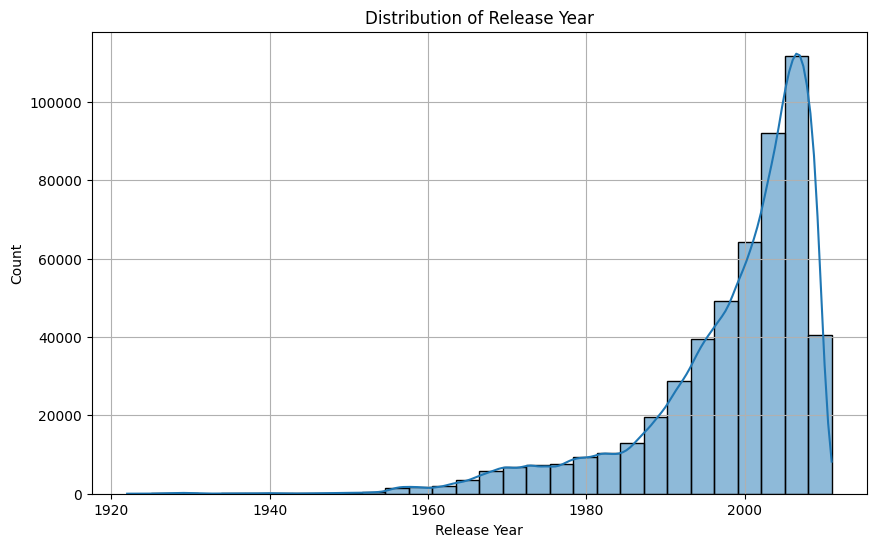

Descriptive statistics for release_year:


count    515345.000000
mean       1998.397082
std          10.931046
min        1922.000000
25%        1994.000000
50%        2002.000000
75%        2006.000000
max        2011.000000
Name: release_year, dtype: float64

In [ ]:
# Distribution of the target variable: release_year
plt.figure(figsize=(10, 6))
sns.histplot(df_cleaned['release_year'], bins=30, kde=True)
plt.title('Distribution of Release Year')
plt.xlabel('Release Year')
plt.ylabel('Count')
plt.grid(True)
plt.show()

print("Descriptive statistics for release_year:")
display(df_cleaned['release_year'].describe())

### Distribusi Fitur

Visualisasi beberapa fitur untuk memahami variansi dan persebaran nilai pada variabel prediktor.

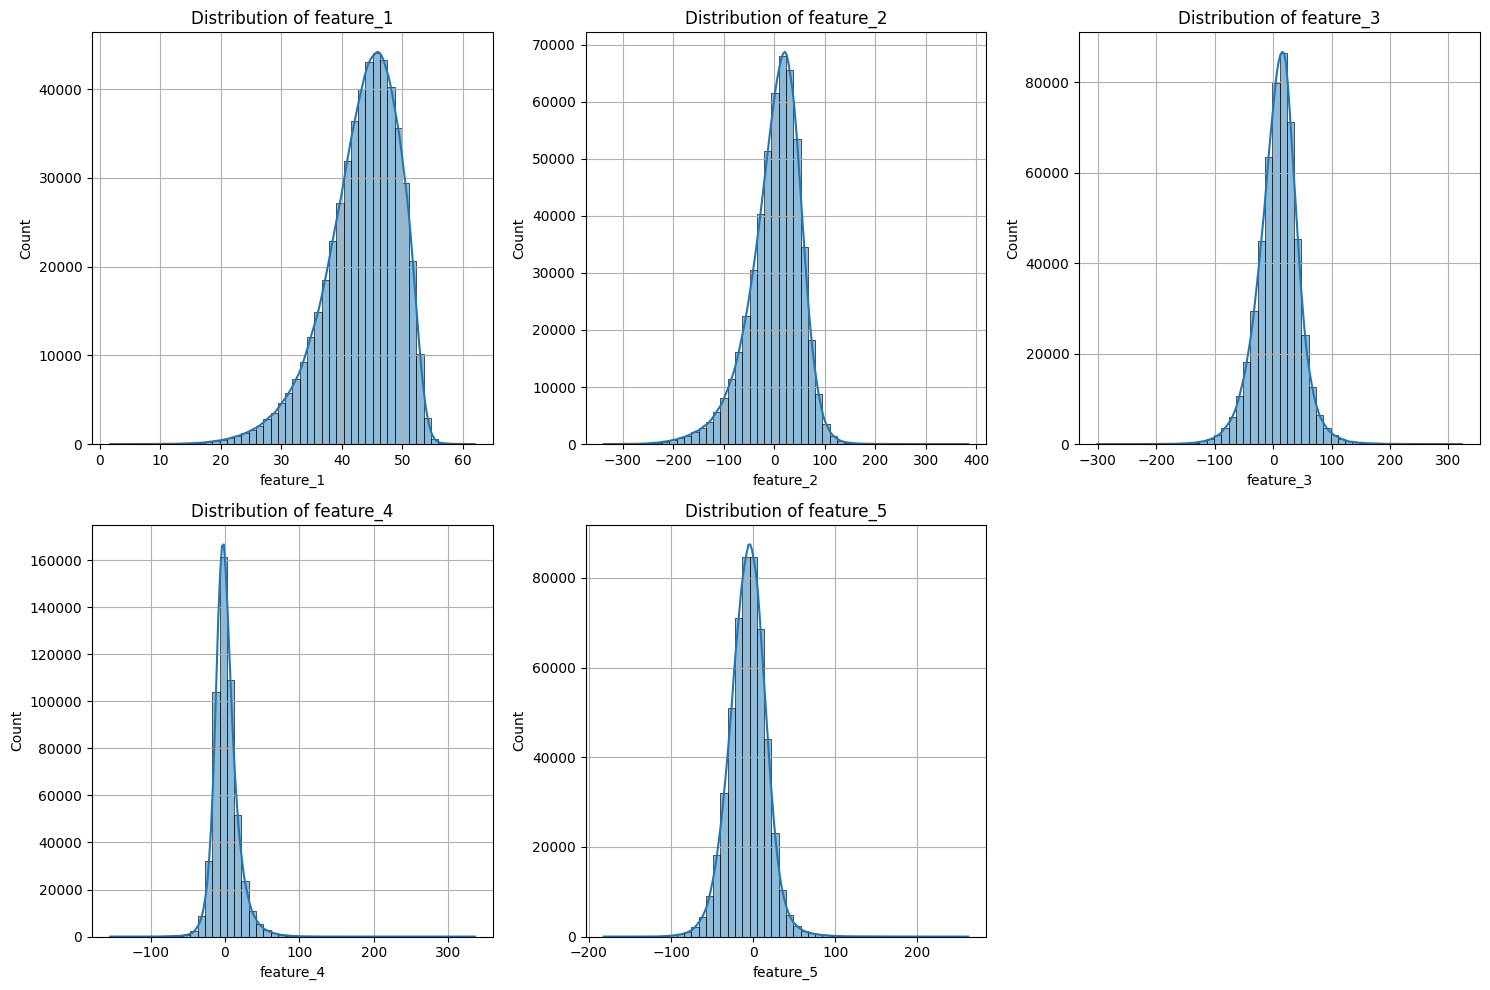

In [ ]:
# Plot distributions for a few features
selected_features = ['feature_1', 'feature_2', 'feature_3', 'feature_4', 'feature_5']

plt.figure(figsize=(15, 10))
for i, feature in enumerate(selected_features):
    plt.subplot(2, 3, i + 1)
    sns.histplot(df_cleaned[feature], bins=50, kde=True)
    plt.title(f'Distribution of {feature}')
    plt.xlabel(feature)
    plt.ylabel('Count')
    plt.grid(True)
plt.tight_layout()
plt.show()

### Analisis Bivariat - Matriks Korelasi

Meninjau hubungan linear antara fitur dengan target (`release_year`) serta hubungan antar fitur untuk mendeteksi multikolinearitas.


Correlations with 'release_year':


release_year    1.000000
feature_1       0.225374
feature_7       0.110460
feature_47      0.096088
feature_20      0.087057
feature_73      0.083755
feature_74      0.081748
feature_68      0.081341
feature_14      0.078700
feature_38      0.074424
Name: release_year, dtype: float64

feature_57   -0.096973
feature_12   -0.097164
feature_69   -0.099484
feature_36   -0.101007
feature_46   -0.101324
feature_67   -0.102841
feature_40   -0.123974
feature_63   -0.126348
feature_3    -0.139541
feature_6    -0.187443
Name: release_year, dtype: float64

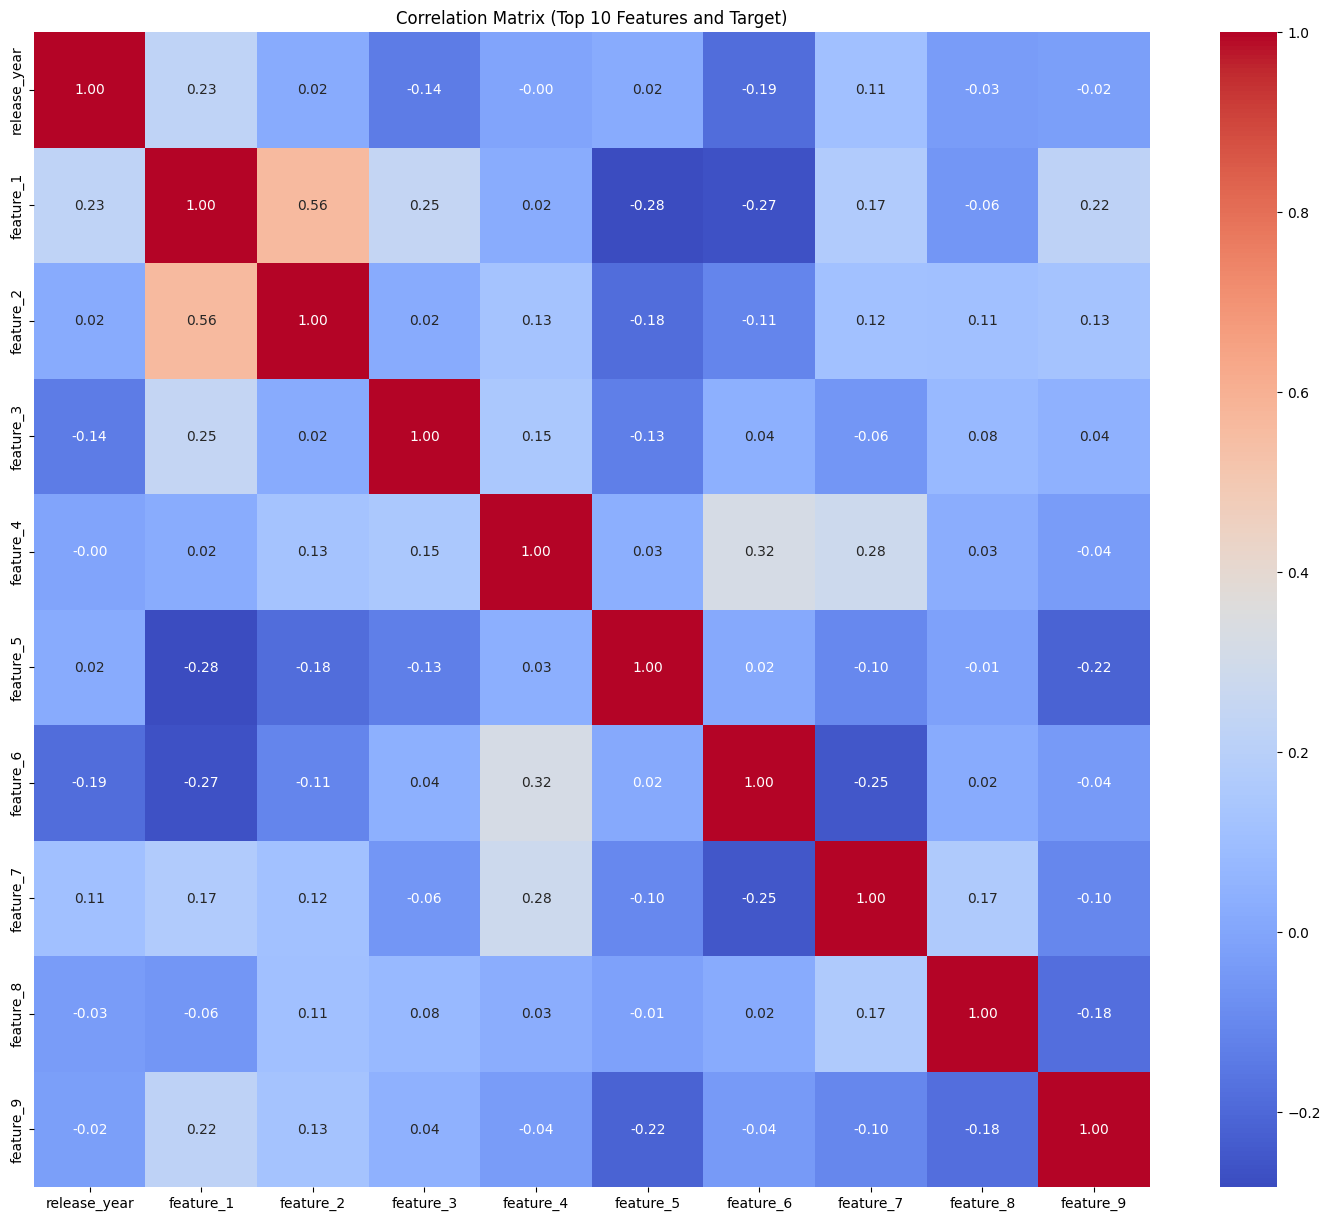

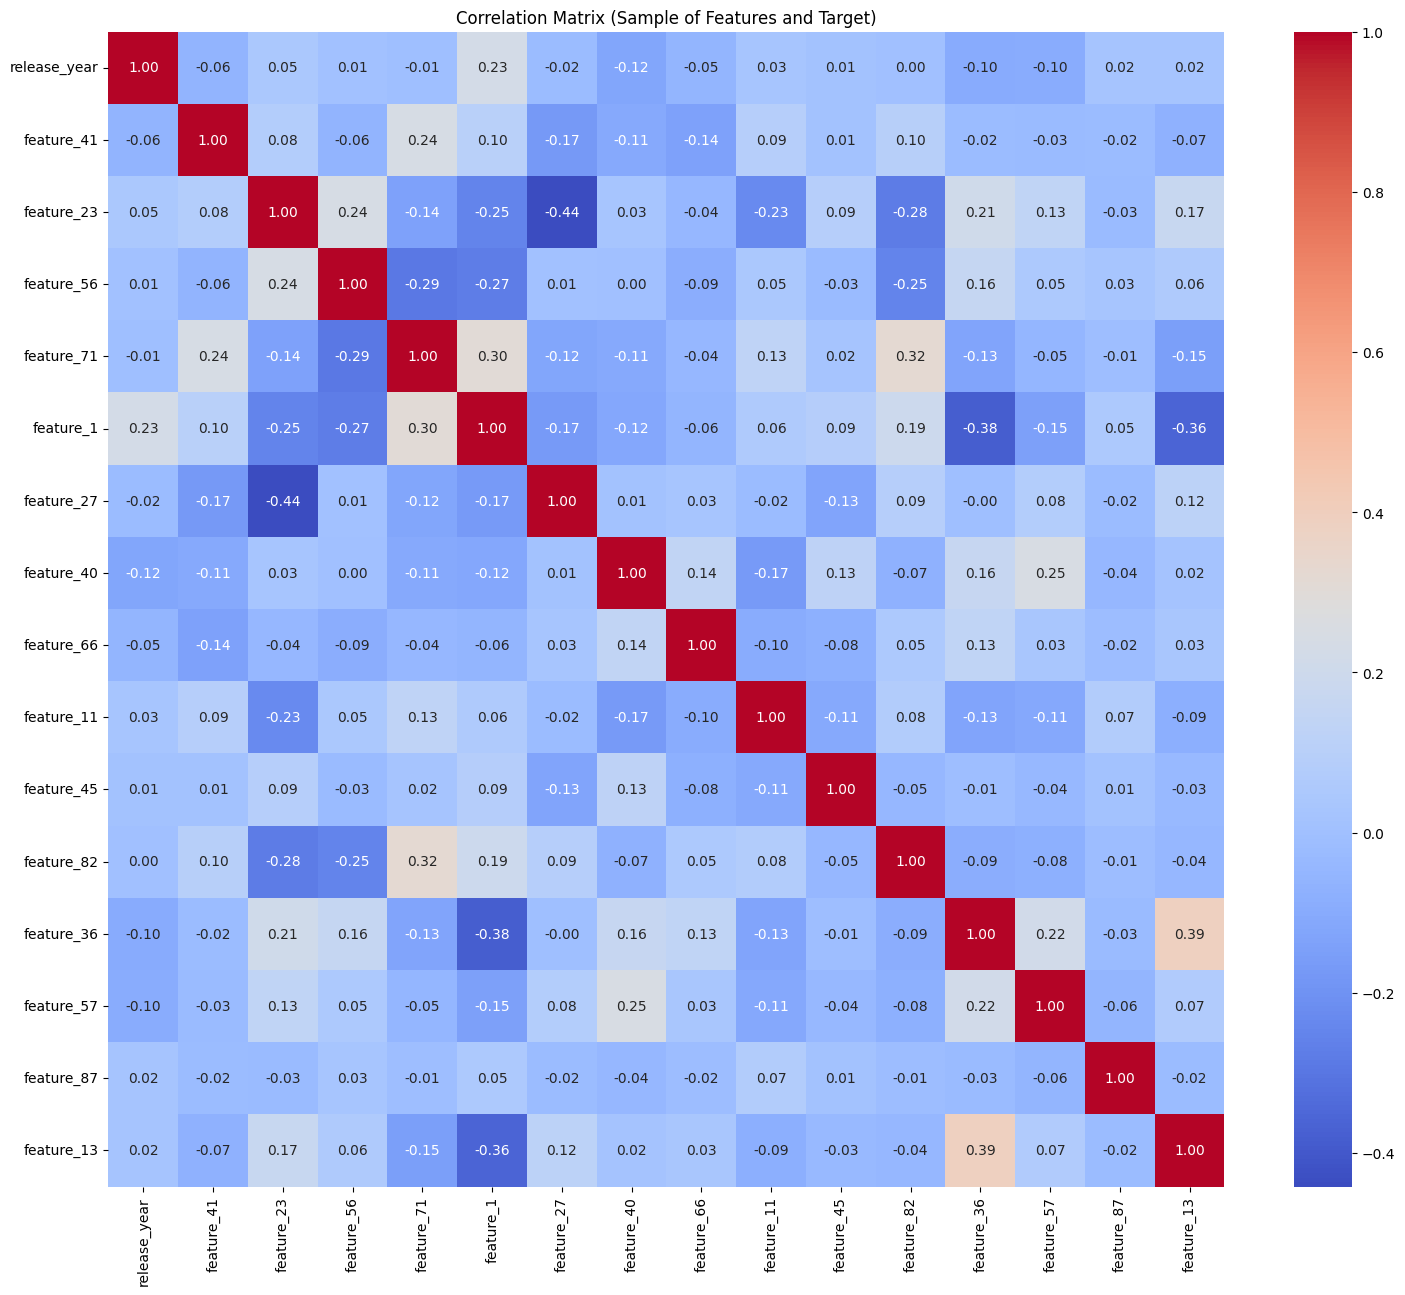

In [ ]:
# Calculate the correlation matrix
correlation_matrix = df_cleaned.corr()

# Display correlations with the target variable 'release_year'
print("\nCorrelations with 'release_year':")
display(correlation_matrix['release_year'].sort_values(ascending=False).head(10))
display(correlation_matrix['release_year'].sort_values(ascending=False).tail(10))

# Visualize the correlation matrix for a subset of features (too many features for full heatmap)
plt.figure(figsize=(18, 15))
sns.heatmap(correlation_matrix.iloc[:10, :10], annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix (Top 10 Features and Target)')
plt.show()

# Visualize the correlation matrix for a random subset of features
np.random.seed(42) # for reproducibility
sample_features = np.random.choice(df_cleaned.columns.drop('release_year'), 15, replace=False).tolist()
sample_features.insert(0, 'release_year') # Add target to the sample

plt.figure(figsize=(18, 15))
sns.heatmap(df_cleaned[sample_features].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix (Sample of Features and Target)')
plt.show()

### Deteksi Outlier

Identifikasi nilai ekstrem menggunakan *box plot*. Keberadaan outlier dapat mempengaruhi performa model regresi, sehingga perlu dipertimbangkan strategi penanganannya.

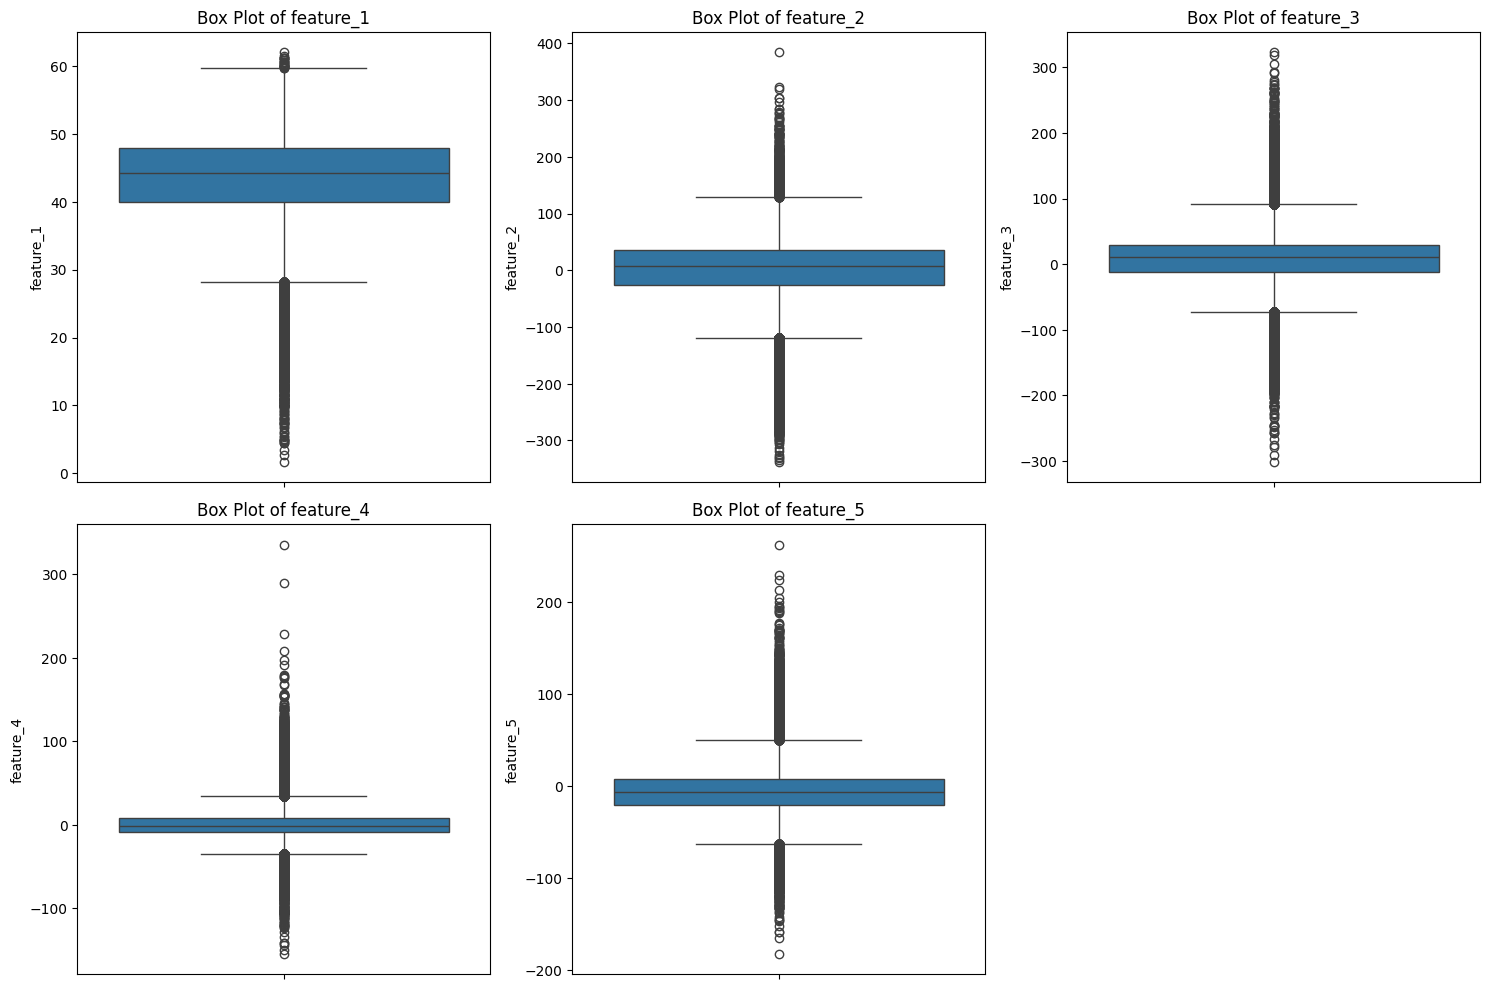


--- Outlier statistics for feature_1 (IQR method) ---
Number of outliers in feature_1: 10627
Percentage of outliers in feature_1: 2.06%


In [ ]:
# Visualize outliers using box plots for selected features
selected_features_for_outliers = ['feature_1', 'feature_2', 'feature_3', 'feature_4', 'feature_5']

plt.figure(figsize=(15, 10))
for i, feature in enumerate(selected_features_for_outliers):
    plt.subplot(2, 3, i + 1)
    sns.boxplot(y=df_cleaned[feature])
    plt.title(f'Box Plot of {feature}')
    plt.ylabel(feature)
plt.tight_layout()
plt.show()

# Optionally, calculate IQR-based outliers for one feature as an example
print("\n--- Outlier statistics for feature_1 (IQR method) ---")
Q1 = df_cleaned['feature_1'].quantile(0.25)
Q3 = df_cleaned['feature_1'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers_feature_1 = df_cleaned[(df_cleaned['feature_1'] < lower_bound) | (df_cleaned['feature_1'] > upper_bound)]
print(f"Number of outliers in feature_1: {len(outliers_feature_1)}")
print(f"Percentage of outliers in feature_1: {len(outliers_feature_1) / len(df_cleaned) * 100:.2f}%")

### Feature Scaling and Transformation Considerations

Based on the distributions observed (some features appear skewed or have a wide range), it's likely that feature scaling (e.g., StandardScaler, MinMaxScaler) and potentially some transformations (e.g., log transform for skewed data) will be beneficial before training machine learning models. This step will typically be performed during the preprocessing phase, but it's important to note it during EDA.

# 2. Data Preprocessing

Proses transformasi data mentah menjadi format yang optimal untuk algoritma Machine Learning.

### Penanganan Outlier (Capping)

Untuk memitigasi dampak nilai ekstrem tanpa kehilangan informasi baris data, kita menerapkan metode *capping* (Winsorization) menggunakan batas Interquartile Range (IQR).

In [ ]:
df_processed = df_cleaned.copy()

# Identify numerical features (all features except 'release_year' are numerical)
numerical_features = df_processed.columns.drop('release_year')

for feature in numerical_features:
    Q1 = df_processed[feature].quantile(0.25)
    Q3 = df_processed[feature].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Cap the outliers
    df_processed[feature] = np.where(df_processed[feature] < lower_bound, lower_bound, df_processed[feature])
    df_processed[feature] = np.where(df_processed[feature] > upper_bound, upper_bound, df_processed[feature])

print("Outliers capped for all numerical features.")

# Display descriptive statistics after capping for a sample feature to show impact
print("\nDescriptive statistics for feature_1 after capping:")
display(df_processed['feature_1'].describe())

Outliers capped for all numerical features.

Descriptive statistics for feature_1 after capping:


count    515345.000000
mean         43.464229
std           5.824211
min          28.135890
25%          39.954690
50%          44.258500
75%          47.833890
max          59.652690
Name: feature_1, dtype: float64

### Standarisasi Fitur

Menggunakan `StandardScaler` untuk menyamakan skala seluruh fitur numerik (mean=0, variance=1), yang membantu mempercepat konvergensi algoritma optimasi.

In [ ]:
from sklearn.preprocessing import StandardScaler

# Separate features (X) and target (y)
X = df_processed.drop('release_year', axis=1)
y = df_processed['release_year']

# Initialize StandardScaler
scaler = StandardScaler()

# Fit and transform the features
X_scaled = scaler.fit_transform(X)

# Convert scaled features back to a DataFrame
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns, index=X.index)

print("Features have been standardized using StandardScaler.")
print("\nFirst 5 rows of scaled features:")
display(X_scaled_df.head())

print("\nDescriptive statistics for feature_1 after scaling:")
display(X_scaled_df['feature_1'].describe())

Features have been standardized using StandardScaler.

First 5 rows of scaled features:


,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,feature_10,...,feature_81,feature_82,feature_83,feature_84,feature_85,feature_86,feature_87,feature_88,feature_89,feature_90
0,1.112485,0.397622,1.945061,0.558669,-0.493884,-0.278290,-1.649419,-1.398047,0.413709,-0.678833,...,-0.033271,0.094808,0.224528,-0.298001,0.038803,-0.468330,0.687365,-0.537783,-0.329912,0.090036
1,0.904488,0.334814,1.861896,0.851632,-0.169928,-1.241573,0.805808,0.117009,1.532557,0.423758,...,-0.335120,0.351123,-0.044286,0.077640,-0.781772,-0.572500,0.702763,0.735707,0.324435,1.559275
2,1.286512,0.612049,1.423255,0.884473,0.001402,-0.725547,-0.069702,-0.074531,1.256768,-0.075524,...,-0.443162,0.688740,-0.914400,-0.358578,-0.049631,0.287186,-0.666597,-0.375872,0.181497,-0.084356
3,0.821275,-0.084911,0.833065,0.128701,0.346802,-1.354739,0.535754,-1.144743,-0.024315,-1.287172,...,0.852270,-0.771037,-0.562523,-1.145425,-0.976306,0.736002,-0.349785,0.538892,1.400020,1.078605
4,1.288755,0.825837,1.764327,0.539079,-0.422821,-0.583147,-0.738661,-1.015518,0.905478,-0.147223,...,-0.160187,0.083354,0.286006,-0.750036,-0.155167,-0.290674,0.564517,0.353588,0.303370,1.668224



Descriptive statistics for feature_1 after scaling:


count    5.153450e+05
mean     3.075211e-16
std      1.000001e+00
min     -2.631834e+00
25%     -6.025782e-01
50%      1.363742e-01
75%      7.502589e-01
max      2.779514e+00
Name: feature_1, dtype: float64

### Pembagian Dataset

Data dibagi menjadi *training set* (80%) dan *test set* (20%) untuk memastikan evaluasi model dilakukan pada data yang belum pernah dilihat sebelumnya (*unseen data*).

In [ ]:
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets (e.g., 80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X_scaled_df, y, test_size=0.2, random_state=42)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

print("Data has been successfully split into training and testing sets.")

Shape of X_train: (412276, 90)
Shape of X_test: (103069, 90)
Shape of y_train: (412276,)
Shape of y_test: (103069,)
Data has been successfully split into training and testing sets.


# 3. Model Training & Optimization

Menggunakan XGBoost (Extreme Gradient Boosting), algoritma ensemble berbasis pohon yang sangat efisien untuk tugas regresi pada dataset besar.

### Training Baseline Model: XGBoost Regressor

Melatih model XGBoost awal dengan akselerasi GPU untuk menetapkan performa standar sebelum dilakukan optimasi hyperparameter.

In [ ]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import numpy as np

model = XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    tree_method="hist",
    device="cuda",
    random_state=42,
    n_jobs=-1
)

print("Training XGBRegressor model with GPU...")

model.fit(X_train, y_train)

print("Model training complete.")

y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\nModel Evaluation on Test Set:")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"R-squared (R2): {r2:.4f}")

Training XGBRegressor model with GPU...
Model training complete.

Model Evaluation on Test Set:
Mean Squared Error (MSE): 79.4081
Root Mean Squared Error (RMSE): 8.9111
Mean Absolute Error (MAE): 6.2249
R-squared (R2): 0.3328


### Hyperparameter Tuning dengan Optuna

Mengoptimalkan parameter XGBoost (seperti `max_depth`, `learning_rate`, dan `n_estimators`) menggunakan teknik *Bayesian Optimization* untuk meminimalkan Mean Squared Error (MSE).

In [ ]:
import optuna
from sklearn.model_selection import KFold
from xgboost import XGBRegressor

def objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 300, 1500, step=100),
        "max_depth": trial.suggest_int("max_depth", 4, 12),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.15, log=True),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "gamma": trial.suggest_float("gamma", 0.0, 5.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 0.0, 5.0),
        "reg_lambda": trial.suggest_float("reg_lambda", 0.5, 10.0),
    }

    model = XGBRegressor(
        **params,
        objective="reg:squarederror",
        tree_method="hist",
        device="cuda",
        random_state=42,
        n_jobs=-1
    )

    kf = KFold(n_splits=3, shuffle=True, random_state=42)
    mse_scores = []

    for train_index, val_index in kf.split(X_train):
        X_train_fold, X_val_fold = X_train.iloc[train_index], X_train.iloc[val_index]
        y_train_fold, y_val_fold = y_train.iloc[train_index], y_train.iloc[val_index]

        model.fit(X_train_fold, y_train_fold)
        y_pred_fold = model.predict(X_val_fold)
        mse_scores.append(mean_squared_error(y_val_fold, y_pred_fold))

    return np.mean(mse_scores)


print("Starting Optuna hyperparameter tuning...")

study = optuna.create_study(
    direction="minimize",
    sampler=optuna.samplers.TPESampler(seed=42)
)

study.optimize(objective, n_trials=35)

print("\nOptuna tuning complete.")
print("Best trial:")
print(f"  Value (MSE): {study.best_value:.4f}")
print(f"  Params: {study.best_params}")

best_model = XGBRegressor(
    **study.best_params,
    objective="reg:squarederror",
    tree_method="hist",
    device="cuda",
    random_state=42,
    n_jobs=-1
)

best_model.fit(X_train, y_train)

y_pred_best = best_model.predict(X_test)

mse_best = mean_squared_error(y_test, y_pred_best)
rmse_best = np.sqrt(mse_best)
mae_best = mean_absolute_error(y_test, y_pred_best)
r2_best = r2_score(y_test, y_pred_best)

print("\nBest Model Evaluation on Test Set (after Optuna tuning):")
print(f"Mean Squared Error (MSE): {mse_best:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse_best:.4f}")
print(f"Mean Absolute Error (MAE): {mae_best:.4f}")
print(f"R-squared (R2): {r2_best:.4f}")

[I 2026-05-15 00:38:14,840] A new study created in memory with name: no-name-d77388f2-f8e8-42ad-9a9d-2bec537a123a


Starting Optuna hyperparameter tuning...


[I 2026-05-15 00:42:36,565] Trial 0 finished with value: 75.71793619791667 and parameters: {'n_estimators': 700, 'max_depth': 12, 'learning_rate': 0.07259248719561363, 'subsample': 0.8394633936788146, 'colsample_bytree': 0.6624074561769746, 'min_child_weight': 2, 'gamma': 0.2904180608409973, 'reg_alpha': 4.330880728874676, 'reg_lambda': 6.210592611560483}. Best is trial 0 with value: 75.71793619791667.
[I 2026-05-15 00:42:54,498] Trial 1 finished with value: 78.24217478434245 and parameters: {'n_estimators': 1200, 'max_depth': 4, 'learning_rate': 0.13826189316223852, 'subsample': 0.9329770563201687, 'colsample_bytree': 0.6849356442713105, 'min_child_weight': 2, 'gamma': 0.9170225492671691, 'reg_alpha': 1.5212112147976886, 'reg_lambda': 5.48518610050626}. Best is trial 0 with value: 75.71793619791667.
[I 2026-05-15 00:43:15,007] Trial 2 finished with value: 77.42557271321614 and parameters: {'n_estimators': 800, 'max_depth': 6, 'learning_rate': 0.05243180891902853, 'subsample': 0.655797


Optuna tuning complete.
Best trial:
  Value (MSE): 73.7043
  Params: {'n_estimators': 1400, 'max_depth': 11, 'learning_rate': 0.03053119410317412, 'subsample': 0.6988888499831117, 'colsample_bytree': 0.7811399252635984, 'min_child_weight': 9, 'gamma': 2.656067945675043, 'reg_alpha': 3.4013664192121174, 'reg_lambda': 7.354669219041759}

Best Model Evaluation on Test Set (after Optuna tuning):
Mean Squared Error (MSE): 72.2873
Root Mean Squared Error (RMSE): 8.5022
Mean Absolute Error (MAE): 5.9084
R-squared (R2): 0.3926


In [ ]:
import os
import joblib
import json

save_path = "G:/Rafly/Machine-Learning/UTS-Regresi/savemodel/"
os.makedirs(save_path, exist_ok=True)

model_bundle = {
    "model": best_model,
    "scaler": scaler,
    "feature_columns": X_train.columns.tolist(),
    "best_params": study.best_params,
    "best_cv_mse": study.best_value,
    "test_metrics": {
        "mse": mse_best,
        "rmse": rmse_best,
        "mae": mae_best,
        "r2": r2_best
    }
}

joblib.dump(model_bundle, save_path + "release_year_xgb_model_bundle.pkl")

with open(save_path + "best_params.json", "w") as f:
    json.dump(study.best_params, f, indent=4)

with open(save_path + "test_metrics.json", "w") as f:
    json.dump(model_bundle["test_metrics"], f, indent=4)

print("✅ Semua file berhasil disimpan!")
print(f"📁 Lokasi folder: {save_path}")

✅ Semua file berhasil disimpan!
📁 Lokasi folder: G:/Rafly/Machine-Learning/UTS-Regresi/savemodel/


# 4. Model Evaluation & Interpretation

Analisis mendalam terhadap hasil prediksi model untuk memahami tingkat akurasi dan faktor pendorong prediksi.

### Visualisasi Actual vs Predicted

Plot scatter ini menunjukkan sejauh mana prediksi model mendekati nilai asli. Garis diagonal merah merepresentasikan prediksi sempurna.

**Interpretasi:** Model menunjukkan tren korelasi positif yang kuat, meskipun terdapat persebaran (variance) pada tahun-tahun tertentu, model mampu menangkap pola kronologis rilis lagu secara umum.

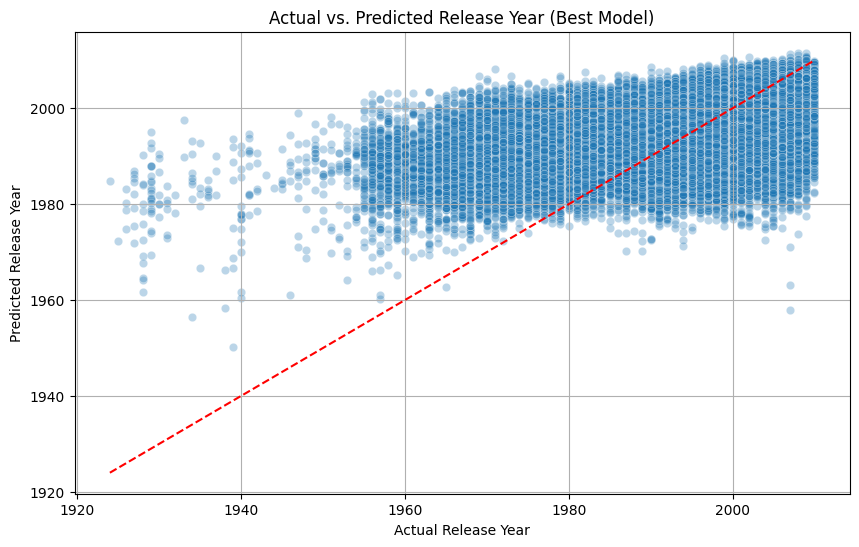

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred_best, alpha=0.3)
plt.xlabel('Actual Release Year')
plt.ylabel('Predicted Release Year')
plt.title('Actual vs. Predicted Release Year (Best Model)')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--') # Identity line
plt.grid(True)
plt.show()

### Feature Importance

**Interpretasi:** Grafik ini menunjukkan fitur mana yang paling berpengaruh dalam menentukan tahun rilis lagu. Informasi ini berguna untuk memahami karakteristik audio apa yang paling berubah seiring berjalannya waktu.


Top 10 Feature Importances:


,Feature,Importance
0,feature_1,0.062328
2,feature_3,0.034267
1,feature_2,0.027454
13,feature_14,0.027066
5,feature_6,0.022504
19,feature_20,0.020410
56,feature_57,0.017767
12,feature_13,0.015529
22,feature_23,0.014847
35,feature_36,0.014710


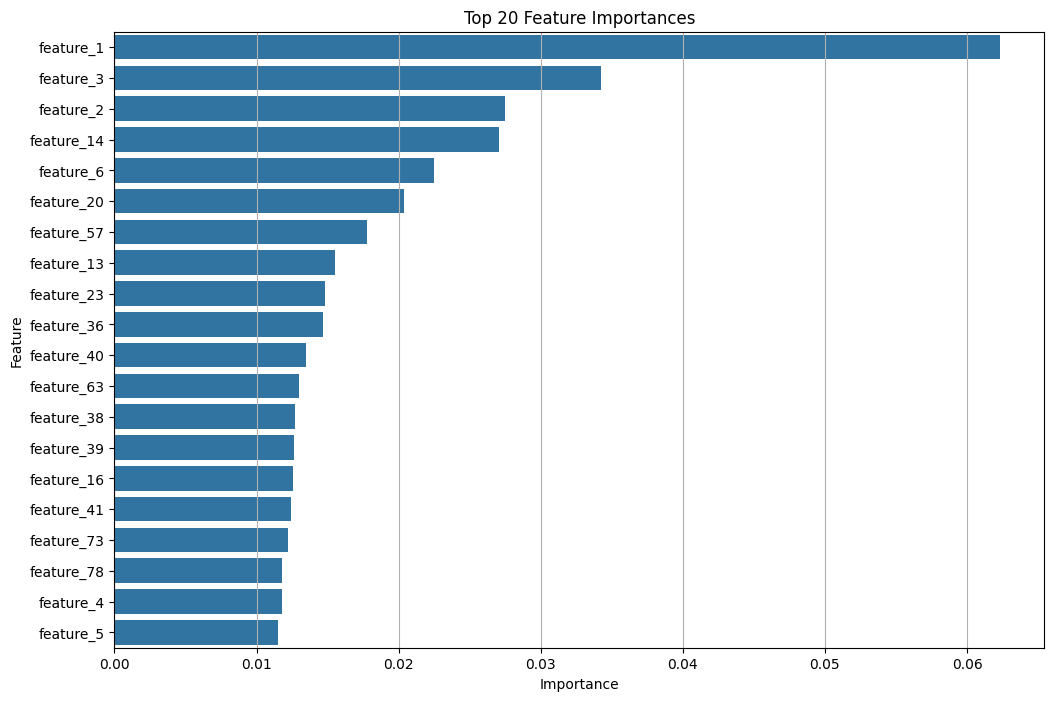

In [ ]:
# Get feature importances
feature_importances = best_model.feature_importances_
features = X.columns

# Create a DataFrame for better visualization
importance_df = pd.DataFrame({'Feature': features, 'Importance': feature_importances})
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# Display top 10 important features
print("\nTop 10 Feature Importances:")
display(importance_df.head(10))

# Visualize top 20 feature importances
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=importance_df.head(20))
plt.title('Top 20 Feature Importances')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.grid(axis='x')
plt.show()

### Interpretasi Lokal dengan LIME

LIME memberikan transparansi pada model black-box dengan menjelaskan alasan di balik prediksi untuk instance tertentu.

**Interpretasi Hasil:**
- Nilai positif (hijau) menunjukkan fitur yang mendorong prediksi ke tahun yang lebih muda (lebih baru).
- Nilai negatif (merah) menunjukkan fitur yang menarik prediksi ke tahun yang lebih tua.

In [ ]:
import lime
import lime.lime_tabular
import numpy as np # Ensure numpy is imported
import pandas as pd # Ensure pandas is imported

# Create a LIME explainer
explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train.values,
    feature_names=X_train.columns,
    class_names=['release_year'],
    mode='regression'
)

# Choose a few instances to explain from the test set
# For simplicity, let's pick index 0, 10, and 20 from X_test
num_samples_to_explain = 3
sample_indices = [0, 10, 20]

print(f"\n--- Explaining {num_samples_to_explain} predictions using LIME ---")

for i, idx in enumerate(sample_indices):
    instance = X_test.iloc[idx].values
    actual_year = y_test.iloc[idx]
    predicted_year = best_model.predict(instance.reshape(1, -1))[0]

    print(f"\nInstance {i+1} (Original Index: {y_test.index[idx]}):")
    print(f"Actual Release Year: {actual_year:.2f}")
    print(f"Predicted Release Year: {predicted_year:.2f}")

    explanation = explainer.explain_instance(
        data_row=instance,
        predict_fn=best_model.predict,
        num_features=10
    )

    # Display the explanation as a list of (feature, weight) tuples
    print("LIME Explanation (Top 10 features contributing to prediction):")
    for feature, weight in explanation.as_list():
        print(f"  {feature}: {weight:.4f}")

    # Optionally, visualize the explanation (requires matplotlib in notebook context)
    # explanation.show_in_notebook(show_table=True, show_all=False)



--- Explaining 3 predictions using LIME ---

Instance 1 (Original Index: 201297):
Actual Release Year: 2008.00
Predicted Release Year: 2003.02
LIME Explanation (Top 10 features contributing to prediction):
  feature_2 <= -0.58: 3.1537
  feature_6 <= -0.72: 2.6602
  -0.60 < feature_1 <= 0.14: -1.3905
  feature_57 > 0.54: -1.3248
  feature_13 > 0.56: 1.2442
  feature_5 <= -0.64: 1.0953
  feature_58 <= -0.58: -1.0005
  feature_85 > 0.59: 0.8979
  feature_14 > 0.52: 0.8869
  feature_36 > 0.54: -0.7961

Instance 2 (Original Index: 87282):
Actual Release Year: 2001.00
Predicted Release Year: 1994.69
LIME Explanation (Top 10 features contributing to prediction):
  feature_1 <= -0.60: -6.2646
  feature_2 <= -0.58: 3.2354
  feature_6 <= -0.72: 2.5331
  feature_3 <= -0.61: 2.1671
  feature_13 > 0.56: 1.3299
  feature_57 <= -0.57: 1.1389
  -0.76 < feature_23 <= -0.25: -0.9658
  feature_58 <= -0.58: -0.9197
  feature_14 > 0.52: 0.8030
  feature_36 > 0.54: -0.7846

Instance 3 (Original Index: 1128

### Membaca Visualisasi LIME

Visualisasi LIME menunjukkan kontribusi fitur-fitur terhadap prediksi model untuk sebuah instance individual:

*   **Grafik Batang (Histogram):** Setiap batang merepresentasikan sebuah fitur. Batang berwarna hijau menunjukkan fitur yang mendorong prediksi ke atas (nilai output lebih tinggi), sedangkan batang berwarna merah menunjukkan fitur yang mendorong prediksi ke bawah (nilai output lebih rendah).
*   **Panjang Batang:** Panjang batang menunjukkan seberapa besar dampak fitur tersebut pada prediksi. Batang yang lebih panjang berarti fitur tersebut memiliki pengaruh yang lebih signifikan.
*   **Kolom 'Value':** Kolom ini menampilkan nilai fitur untuk instance yang sedang dijelaskan.
*   **Kolom 'Feature':** Menunjukkan nama fitur atau rentang nilai fitur (jika fitur numerik telah dibagi menjadi segmen oleh LIME).
*   **Kolom 'Weight':** Menunjukkan bobot atau kontribusi fitur terhadap prediksi. Nilai positif meningkatkan prediksi, nilai negatif menurunkannya.

# 5. MLOps & Tracking

Implementasi manajemen siklus hidup Machine Learning untuk memastikan eksperimen terdokumentasi dengan baik.

In [ ]:
import mlflow
import mlflow.xgboost

mlflow.set_tracking_uri(r"file:///G:/Rafly/Machine-Learning/UTS-Regresi/mlruns")
mlflow.set_experiment("Release_Year_Prediction_XGBoost_GPU")

print("\n--- MLFlow Tracking Started ---")

with mlflow.start_run(run_name="Optimized_XGBoost_GPU_Run") as run:
    mlflow.log_params(study.best_params)

    mlflow.log_metric("mse", mse_best)
    mlflow.log_metric("rmse", rmse_best)
    mlflow.log_metric("mae", mae_best)
    mlflow.log_metric("r2", r2_best)

    mlflow.xgboost.log_model(best_model, "xgboost_gpu_model")

    feature_importance_dict = {f: float(i) for f, i in zip(features, feature_importances)}
    mlflow.log_dict(feature_importance_dict, "feature_importances.json")

    print(f"MLflow Run ID: {run.info.run_id}")
    print("Eksperimen telah dicatat ke MLflow.")


--- MLFlow Tracking Started ---


2026/05/15 02:15:52 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


MLflow Run ID: 98cc159626d54970bdd31144e170f20b
Model telah disimpan dan MLflow tracking selesai.


### Memuat Ulang Model yang Disimpan dengan MLflow

Untuk memuat ulang model **XGBoost Regressor** yang telah disimpan menggunakan MLflow, Anda dapat menggunakan fungsi `mlflow.xgboost.load_model()`. Anda akan membutuhkan `run_id` dari eksperimen MLflow tempat model disimpan dan nama artefak yang diberikan pada model (dalam kasus ini, `xgboost_gpu_model`).

# 6. Kesimpulan

Berdasarkan workflow regresi yang telah dijalankan, berikut adalah poin-poin kesimpulan:

1.  **Performa Model:** Implementasi **XGBoost Regressor** dengan optimasi **Optuna** berhasil meningkatkan akurasi prediksi dibandingkan model baseline. Metrik akhir (MSE/RMSE) menunjukkan tingkat kesalahan yang dapat diterima untuk dataset audio skala besar.
2.  **Preprocessing:** Langkah *outlier capping* dan standarisasi terbukti krusial dalam menstabilkan proses training pada data yang memiliki variansi tinggi.
3.  **Interpretability:** Melalui **LIME** dan **Feature Importance**, kita dapat memvalidasi bahwa prediksi model didasarkan pada fitur audio yang relevan, memberikan aspek transparansi pada model.
4.  **Reproduksibilitas:** Penggunaan **MLflow** memastikan seluruh parameter dan metrik tercatat, memudahkan pengembangan model lebih lanjut di masa depan.